# Bayesian k-NN probability heat map

Set `DATASET` to `moon`, `iris`, or `gaussian`, then run the cells.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "bayesian_knn").is_dir() and (project_root.parent / "bayesian_knn").is_dir():
    project_root = project_root.parent
if (project_root / "bayesian_knn").is_dir():
    sys.path.insert(0, str(project_root))

from bayesian_knn.experiments.classification_2d import (
    format_convergence_history,
    plot_probability_heatmap,
    run_2d_classification_experiment,
)

In [2]:
DATASET = "moon"  # Other options: "iris", "gaussian"

DATA_PARAMETERS = {
    "n_samples": 600,
    "noise": 0.24,
    "random_state": 7,
    "feature_indices": (0, 1),
    "mean_distance": 3.0,
    "standard_deviation": 1.0,
}

SPLIT_PARAMETERS = {
    "test_size": 0.30,
    "split_random_state": 7,
}

MODEL_PARAMETERS = {
    "n_estimators": "auto",
    "max_estimators": 640,
    "tolerance": 0.01,
    "convergence_metric": "median",
    "convergence_size": 256,
    "cv": 5,
    "max_neighbors": None,
    "weights": "distance",
    "n_jobs": -1,
    "random_state": 12,
}

PLOT_PARAMETERS = {
    "padding": 0.55,
    "grid_size": 350,
    "class_label": None,
    "output_path": None,
}

In [3]:
result = run_2d_classification_experiment(
    DATASET,
    dataset_parameters=DATA_PARAMETERS,
    **SPLIT_PARAMETERS,
    model_parameters=MODEL_PARAMETERS,
)
print(f"dataset: {result.dataset}")
print(f"test accuracy: {result.test_accuracy:.3f}")
print(f"estimators used: {result.model.n_estimators_}")
print(f"converged: {result.model.converged_}")
print(format_convergence_history(result))

dataset: moon
test accuracy: 0.933
estimators used: 160
converged: True
20 estimators: initial ensemble
40 estimators: median probability change = 0.031518
80 estimators: median probability change = 0.016077
160 estimators: median probability change = 0.009415


/Users/f.costa/.venvs/py312/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


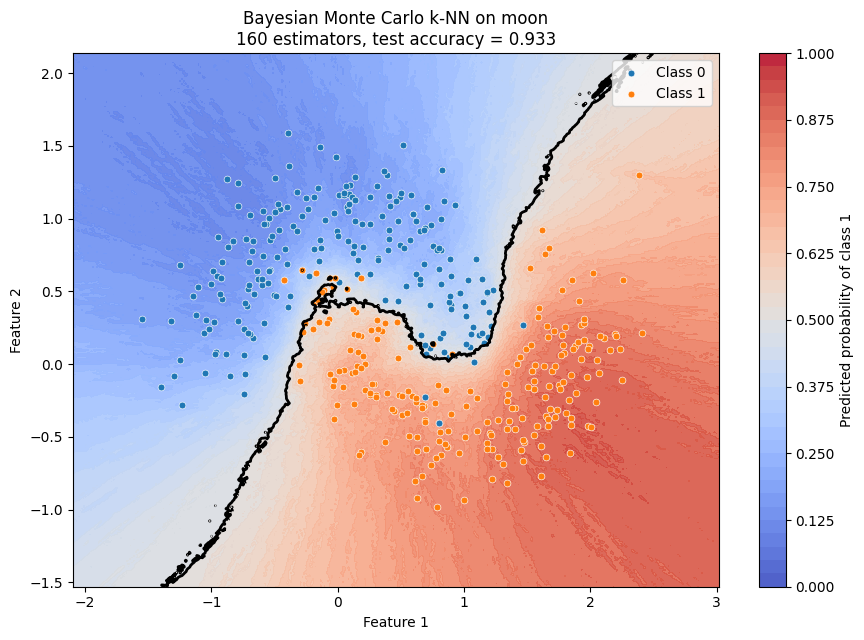

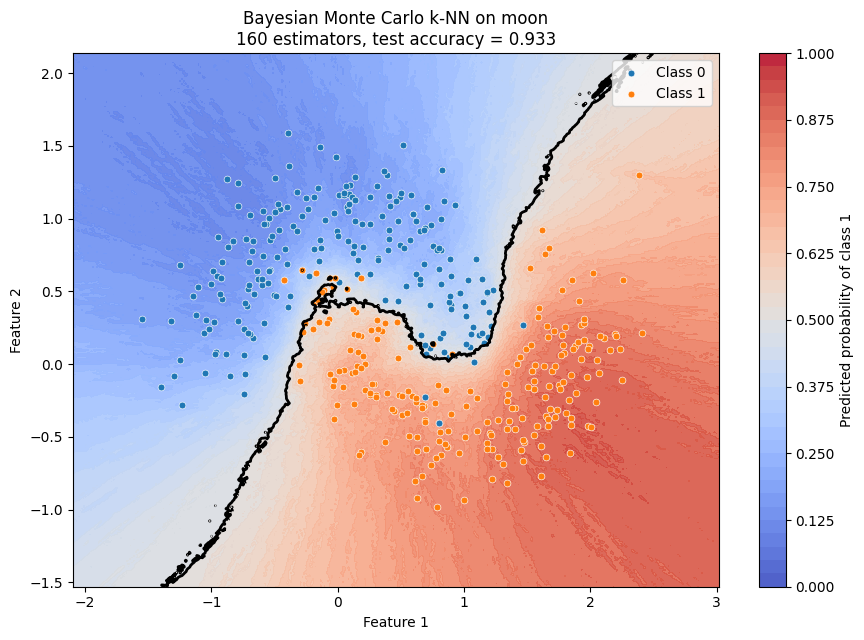

In [4]:
_ = plot_probability_heatmap(result, **PLOT_PARAMETERS)